In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
input_path = "data/"

In [ ]:
def print_file_size(input_path,subset):
    print('{}:'.format(subset))
    print('')
    path=input_path + subset + '/'
    for f in os.listdir(path):
        if not os.path.isdir(path + f):
            print(f.ljust(30) + str(round(os.path.getsize(path + f)/1000000,2)) + 'MB')
        else:
            sizes = [os.path.getsize(path+f+'/'+x)/1000000 for x in os.listdir(path + f)]
            print(f.ljust(30) + str(round(sum(sizes),2))+ 'MB' + '({} files)' .format(len(sizes)))
    print('')



print_file_size(input_path,'train_another')
print_file_size(input_path,'validation_another')
print_file_size(input_path,'test_another')
print_file_size(input_path,'test')

train_another:

damage                        12.56MB(5000 files)
no_damage                     15.07MB(5000 files)

validation_another:

damage                        2.52MB(1000 files)
no_damage                     3.02MB(1000 files)

test_another:

damage                        20.12MB(8000 files)
no_damage                     3.01MB(1000 files)

test:

damage                        2.53MB(1000 files)
no_damage                     2.99MB(1000 files)



In [ ]:
import os

def delete_non_convertible_images(root_folder):
    for foldername, subfolders, filenames in os.walk(root_folder):  # `filenames` is a list
        for filename in filenames:  # Iterate over each file
            try:
                # Attempt to extract coordinates from the filename
                lon, lat = map(float, os.path.splitext(filename)[0].split('_'))
            except ValueError:
                # If conversion to float fails, delete the image
                image_path = os.path.join(foldername, filename)
                print(f"Deleting: {image_path}")  # Debugging statement
                os.remove(image_path)  # Uncomment this to actually delete

# Replace 'path_to_folder' with actual path to your root folder
root_folder = "input_path"
delete_non_convertible_images(root_folder)


In [ ]:
import pandas as pd
from pathlib import Path
image_df = pd.DataFrame({'path': list(Path(input_path).glob('**/*.jp*g'))})

image_df['damage'] = image_df['path'].map(lambda x: x.parent.stem)
image_df['data_split'] = image_df['path'].map(lambda x: x.parent.parent.stem)
image_df['location'] = image_df['path'].map(lambda x: x.stem)
image_df['lon'] = image_df['location'].map(lambda x: float(x.split('_')[0]))
image_df['lat'] = image_df['location'].map(lambda x: float(x.split('_')[-1]))
image_df['path'] = image_df['path'].map(lambda x: str(x)) #convert path back to string


image_df.head()

,path,damage,data_split,location,lon,lat
0,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.548123_30.900623,-93.548123,30.900623
1,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.560128_30.894917,-93.560128,30.894917
2,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.578271_30.779923999999998,-93.578271,30.779924
3,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.590598_30.694956,-93.590598,30.694956
4,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.604017_30.793719,-93.604017,30.793719


In [ ]:
image_df


,path,damage,data_split,location,lon,lat
0,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.548123_30.900623,-93.548123,30.900623
1,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.560128_30.894917,-93.560128,30.894917
2,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.578271_30.779923999999998,-93.578271,30.779924
3,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.590598_30.694956,-93.590598,30.694956
4,C:\Users\faris\Desktop\mini2\dataset\test\dama...,damage,test,-93.604017_30.793719,-93.604017,30.793719
...,...,...,...,...,...,...
45995,C:\Users\faris\Desktop\mini2\validation_anothe...,no_damage,validation_another,-97.000188_28.879426000000002,-97.000188,28.879426
45996,C:\Users\faris\Desktop\mini2\validation_anothe...,no_damage,validation_another,-97.000443_28.859588000000002,-97.000443,28.859588
45997,C:\Users\faris\Desktop\mini2\validation_anothe...,no_damage,validation_another,-97.000872_28.789737,-97.000872,28.789737
45998,C:\Users\faris\Desktop\mini2\validation_anothe...,no_damage,validation_another,-97.000945_28.846922999999997,-97.000945,28.846923


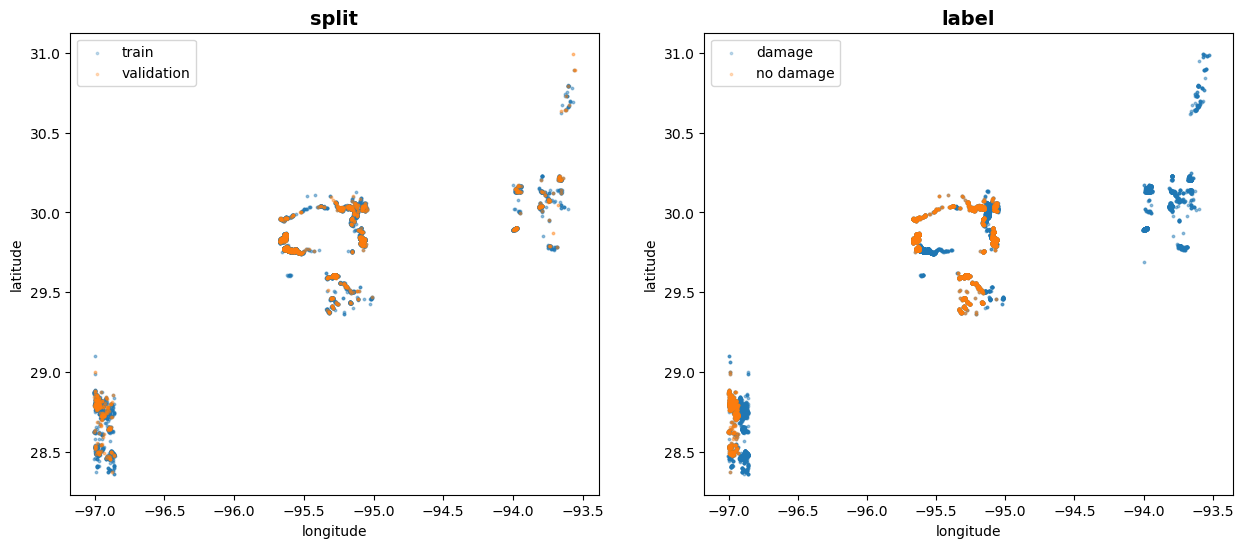

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6))

s = 3
alpha = 0.25

# get the train-validation-test splits
image_df_train = image_df[image_df['data_split']=='train_another'].copy()
image_df_val = image_df[image_df['data_split']=='validation_another'].copy()
image_df_test = image_df[image_df['data_split']=='test_another'].copy()

# sort to ensure reproducible behaviour
image_df_train.sort_values('lat', inplace=True)
image_df_val.sort_values('lat', inplace=True)
image_df_test.sort_values('lat', inplace=True)
image_df_train.reset_index(drop=True,inplace=True)
image_df_val.reset_index(drop=True,inplace=True)
image_df_test.reset_index(drop=True,inplace=True)

ax[0].scatter(image_df_train['lon'], image_df_train['lat'], color='C0', s=s, alpha=alpha, label='train')
ax[0].scatter(image_df_val['lon'], image_df_val['lat'], color='C1', s=s, alpha=alpha, label='validation')

ax[0].set_title('split', fontsize=14, fontweight='bold')
ax[0].legend()
ax[0].set_xlabel('longitude')
ax[0].set_ylabel('latitude')

image_df_dmg = image_df[image_df['damage']=='damage'].copy()
image_df_nodmg = image_df[image_df['damage']=='no_damage'].copy()

image_df_dmg.reset_index(drop=True,inplace=True)
image_df_nodmg.reset_index(drop=True,inplace=True)

ax[1].scatter(image_df_dmg['lon'], image_df_dmg['lat'], color='C0', s=s, alpha=alpha, label='damage')
ax[1].scatter(image_df_nodmg['lon'], image_df_nodmg['lat'], color='C1', s=s, alpha=alpha, label='no damage')

ax[1].set_title('label', fontsize=14, fontweight='bold')
ax[1].legend()
ax[1].set_xlabel('longitude')
ax[1].set_ylabel('latitude')

plt.show(fig)


In [ ]:
print(f"Train Data Size: {len(image_df_train)}")
print(f"Validation Data Size: {len(image_df_val)}")


Train Data Size: 20000
Validation Data Size: 4000


In [ ]:
print(image_df['data_split'].unique())


['test' 'test_another' 'train_another' 'validation_another']


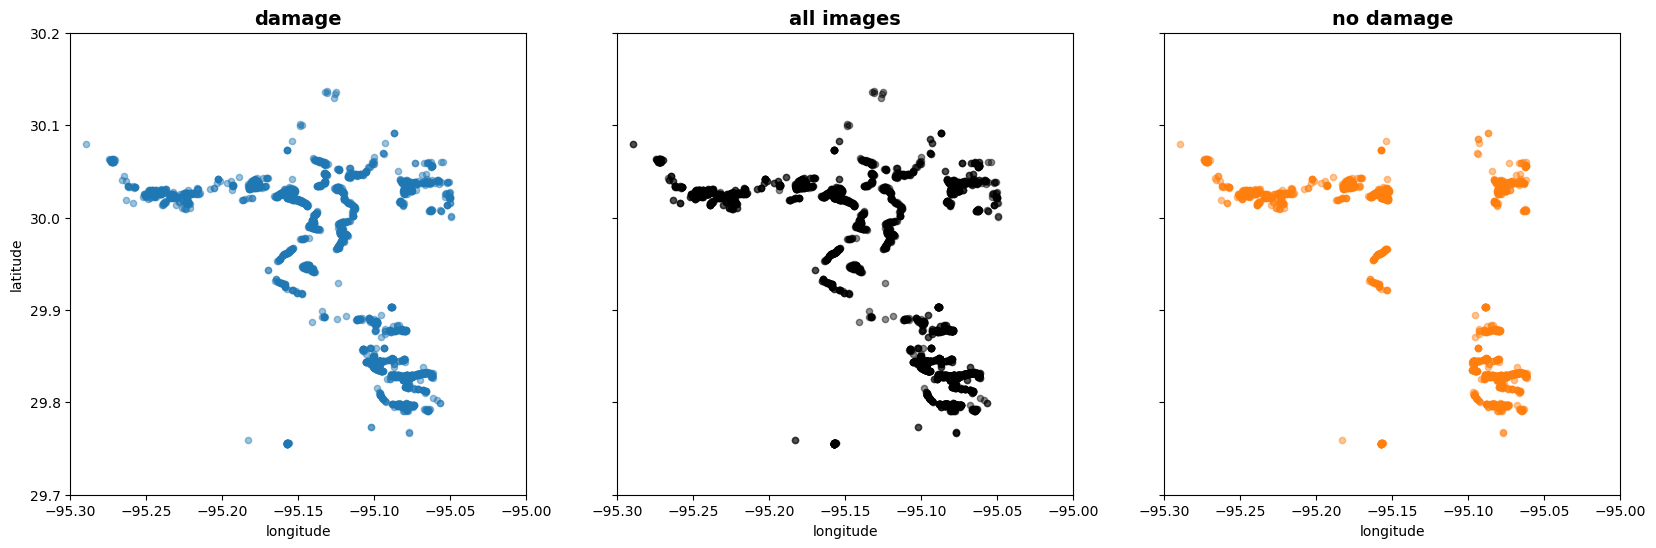

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,6), sharex=True, sharey=True)

s = 20
alpha = 0.25

ax[0].scatter(image_df_dmg['lon'], image_df_dmg['lat'], color='C0', s=s, alpha=alpha, label='damage')
ax[0].set_title('damage', fontsize=14, fontweight='bold')

ax[1].scatter(image_df_dmg['lon'], image_df_dmg['lat'], color='k', s=s, alpha=alpha, label='damage')
ax[1].scatter(image_df_nodmg['lon'], image_df_nodmg['lat'], color='k', s=s, alpha=alpha, label='no damage')
ax[1].set_title('all images', fontsize=14, fontweight='bold')

ax[2].scatter(image_df_nodmg['lon'], image_df_nodmg['lat'], color='C1', s=s, alpha=alpha, label='no damage')
ax[2].set_title('no damage', fontsize=14, fontweight='bold')

ax[0].set_ylabel('latitude')
ax[0].set_xlabel('longitude')
ax[1].set_xlabel('longitude')
ax[2].set_xlabel('longitude')

ax[0].set_xlim(-95.3,-95)
ax[0].set_ylim(29.7,30.2)

plt.show(fig)


TRAINING DATASET


In [ ]:
# reading images
import cv2
img = cv2.imread(image_df['path'][0],cv2.IMREAD_UNCHANGED)
np.shape(img)

(128, 128, 3)

In [ ]:
type(img[0,0,0])

numpy.uint8

In [ ]:
np.min(img[:,:,:])

0

In [ ]:
np.max(img[:,:,:])

255

plots

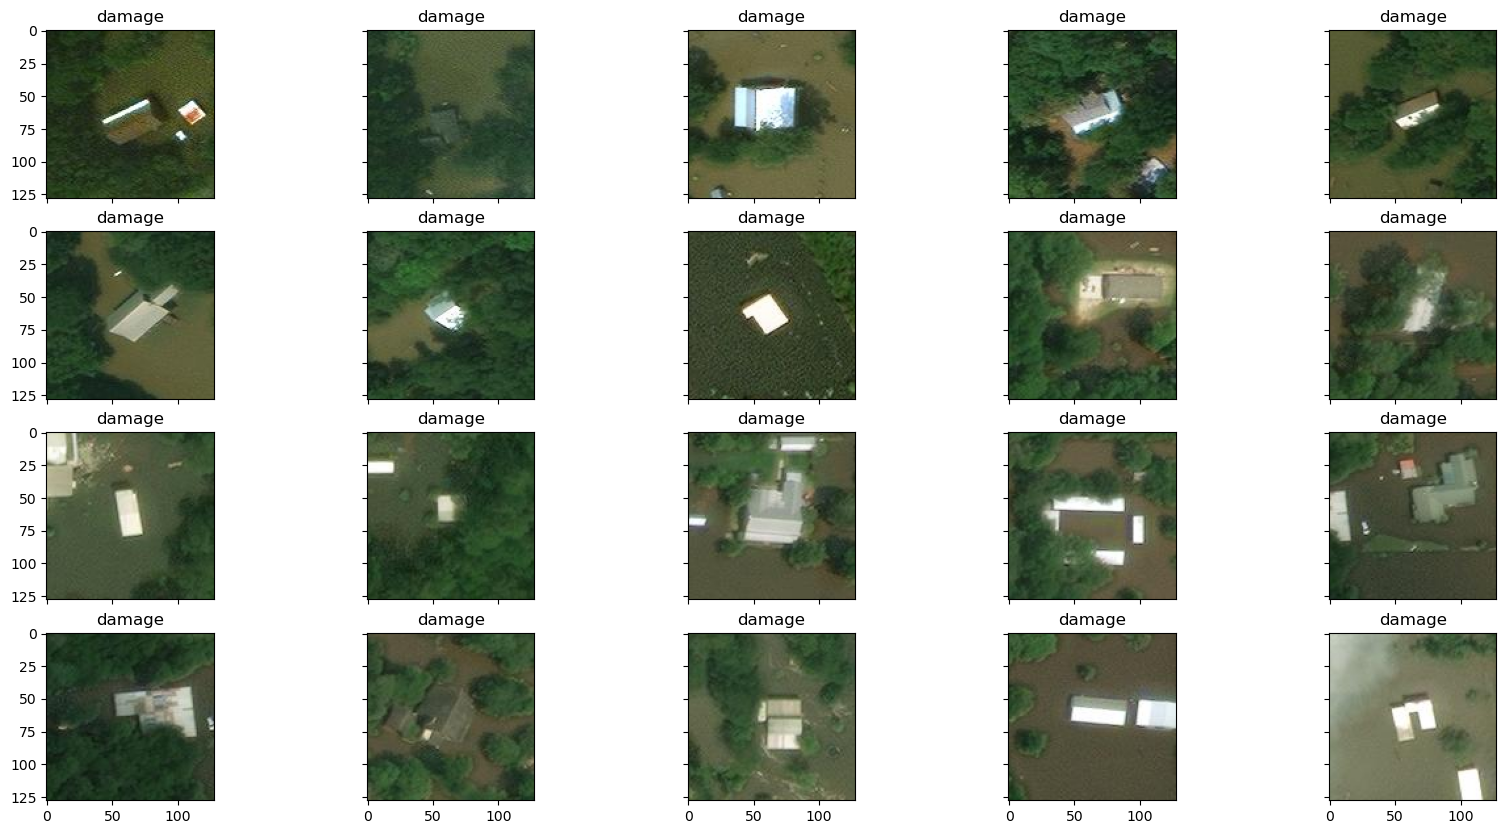

In [ ]:
fig ,ax = plt.subplots(nrows = 4,ncols = 5, sharex=True,sharey = True , figsize = (20,10))
ax = ax.flatten()

for i in range(20):
    img = cv2.imread(image_df_dmg['path'][i],cv2.IMREAD_UNCHANGED)
    ax[i].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    ax[i].set_title('damage')


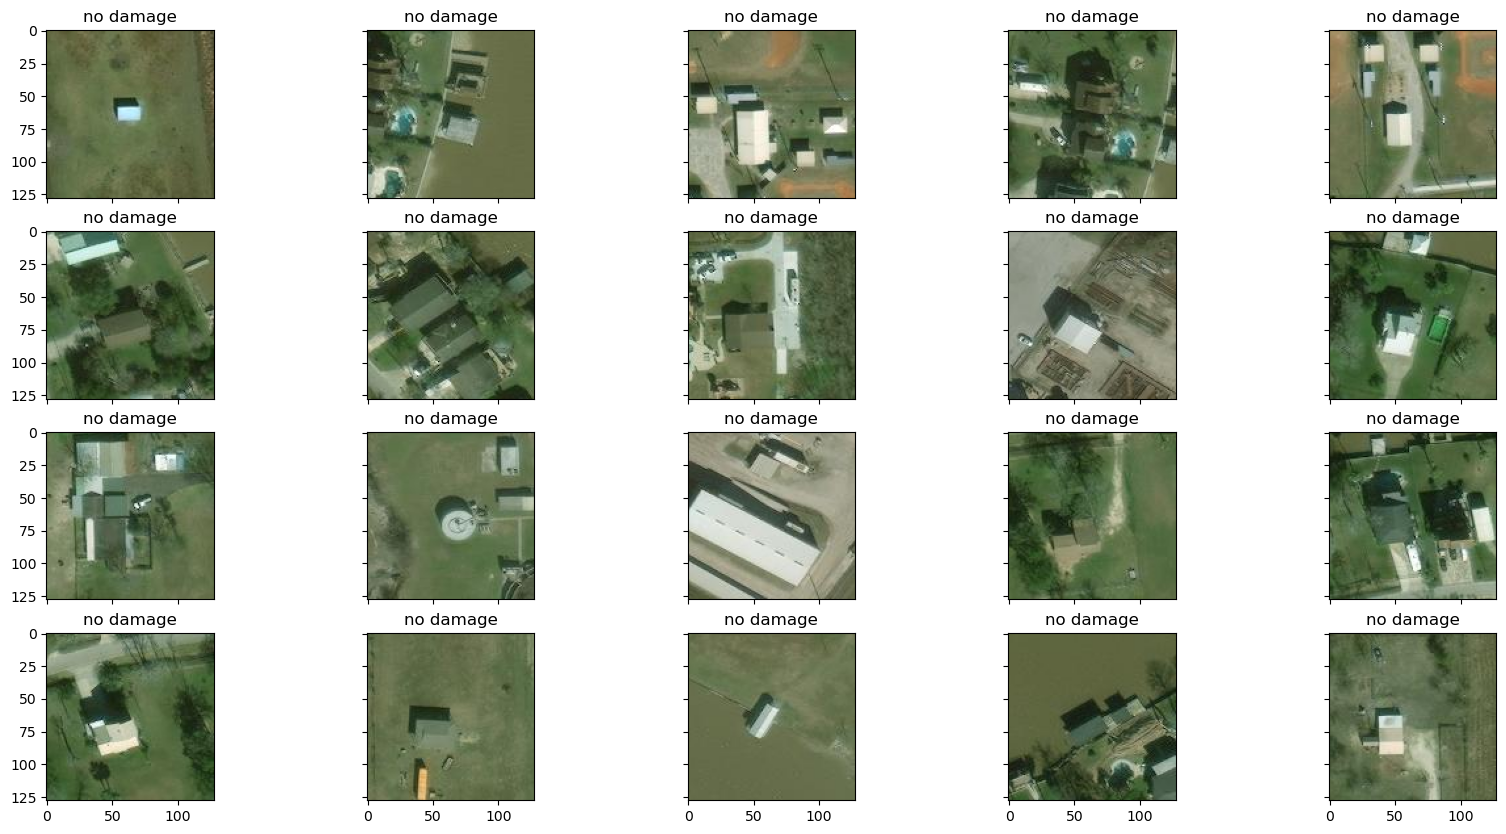

In [ ]:
fig ,ax = plt.subplots(nrows = 4,ncols = 5, sharex=True,sharey = True , figsize = (20,10))
ax = ax.flatten()
for i in range(20):
    img = cv2.imread(image_df_nodmg['path'][i],cv2.IMREAD_UNCHANGED)
    ax[i].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    ax[i].set_title('no damage')

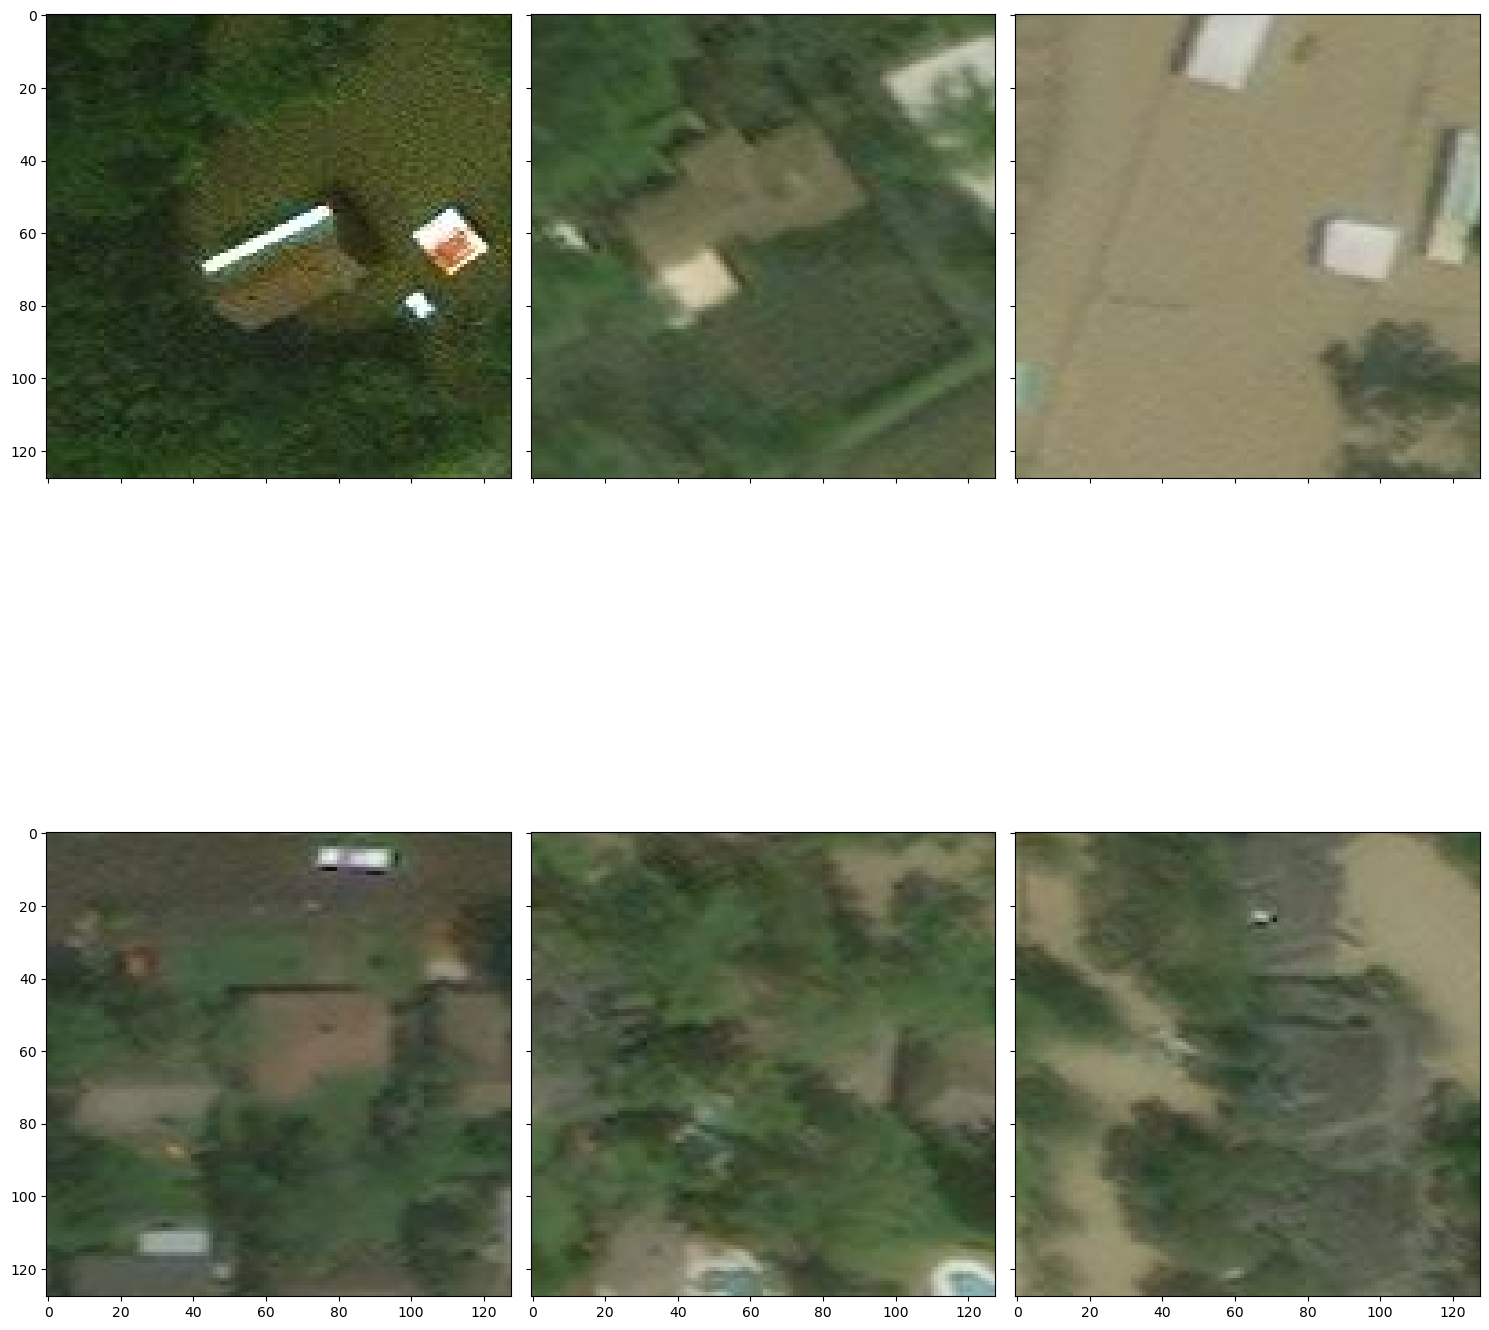

In [ ]:
fig , ax = plt.subplots(nrows=2 ,ncols=3,sharex=True,sharey=True,figsize=(15,20))
ax = ax.flatten()

selected_dmg = np.array([0,1,2,3,4,5]) * 100

for i in range(6):
    img = cv2.imread(image_df_dmg['path'][selected_dmg[i]], cv2.IMREAD_UNCHANGED)
    ax[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    #ax[i].set_title('damage')


fig.tight_layout()
plt.show()


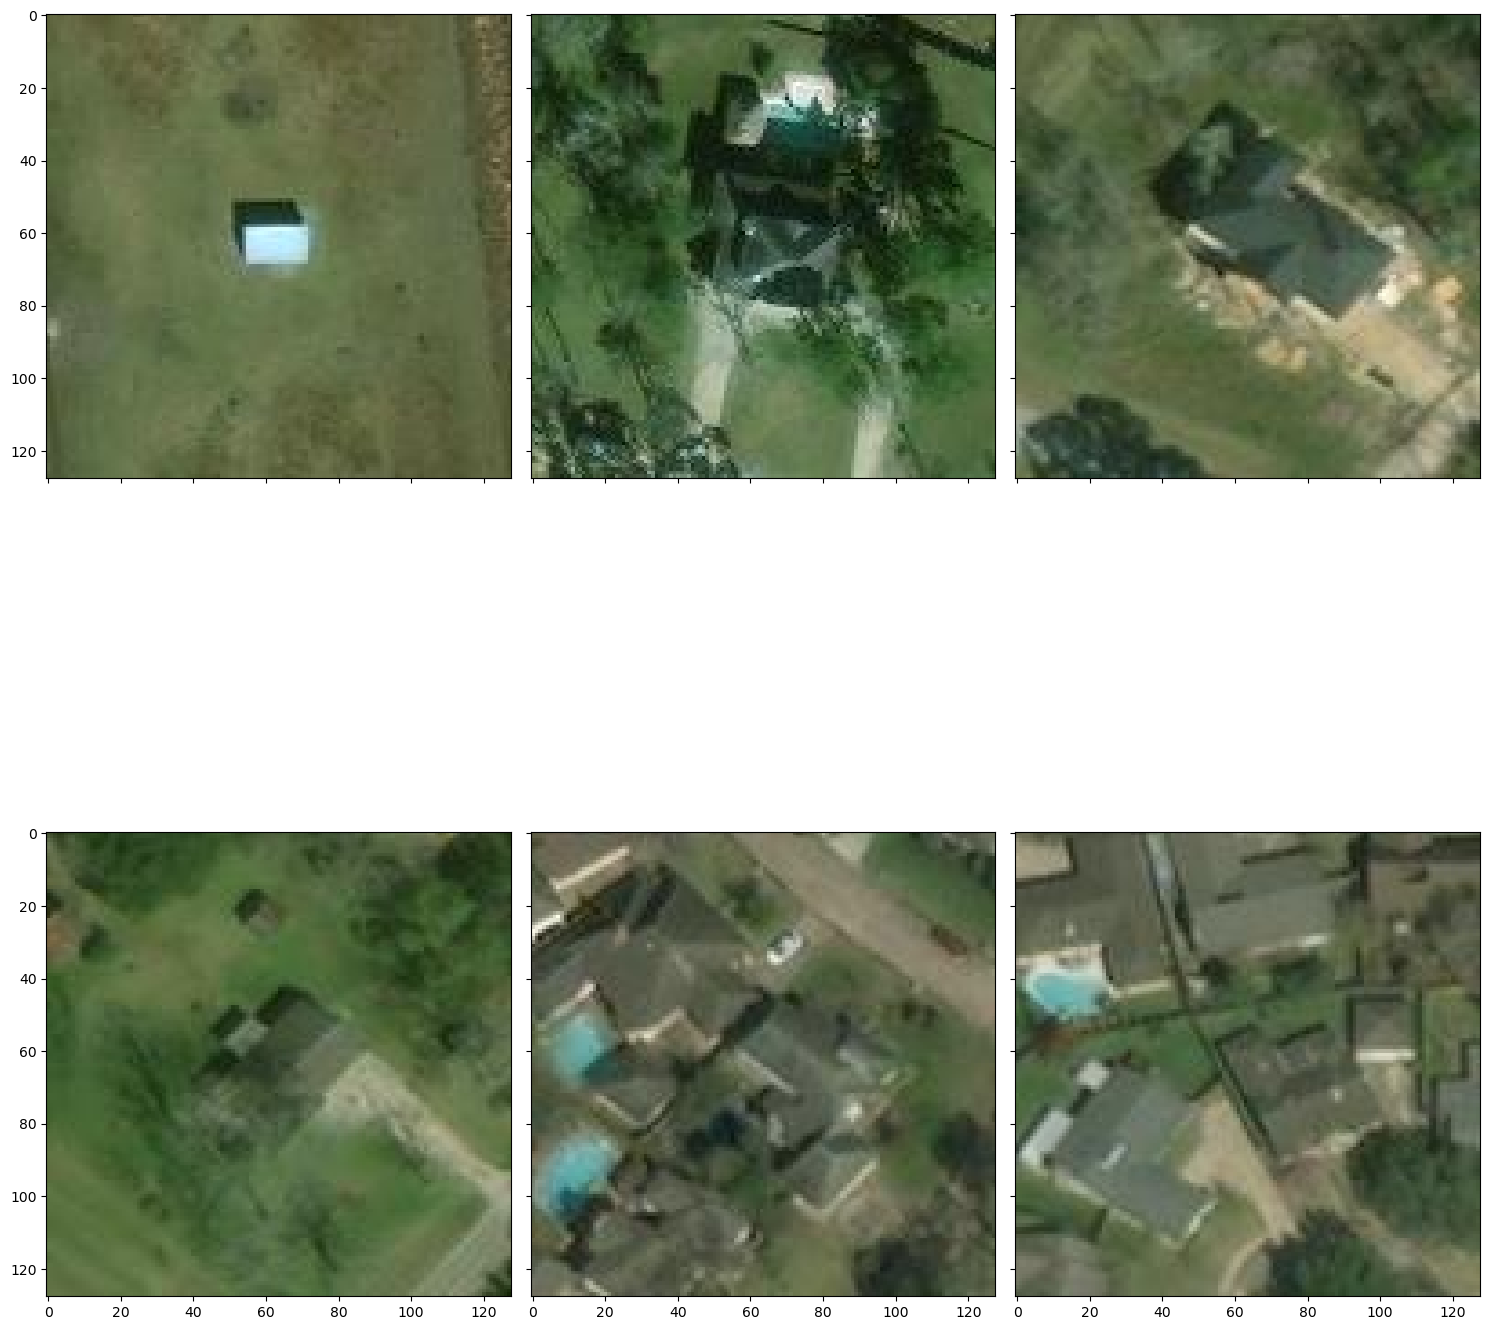

In [ ]:
fig , ax = plt.subplots(nrows=2 ,ncols=3,sharex=True,sharey=True,figsize=(15,20))
selected_nomdg = np.array([0,1,2,3,4,5]) * 99
ax = ax.flatten()
for i in range(6):
    img = cv2.imread(image_df_nodmg['path'][selected_nomdg[i]], cv2.IMREAD_UNCHANGED)
    ax[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    #ax[i+6].set_title('no damage')
fig.tight_layout()
plt.show()

Histogram of Pixel Values for Each Color Channel


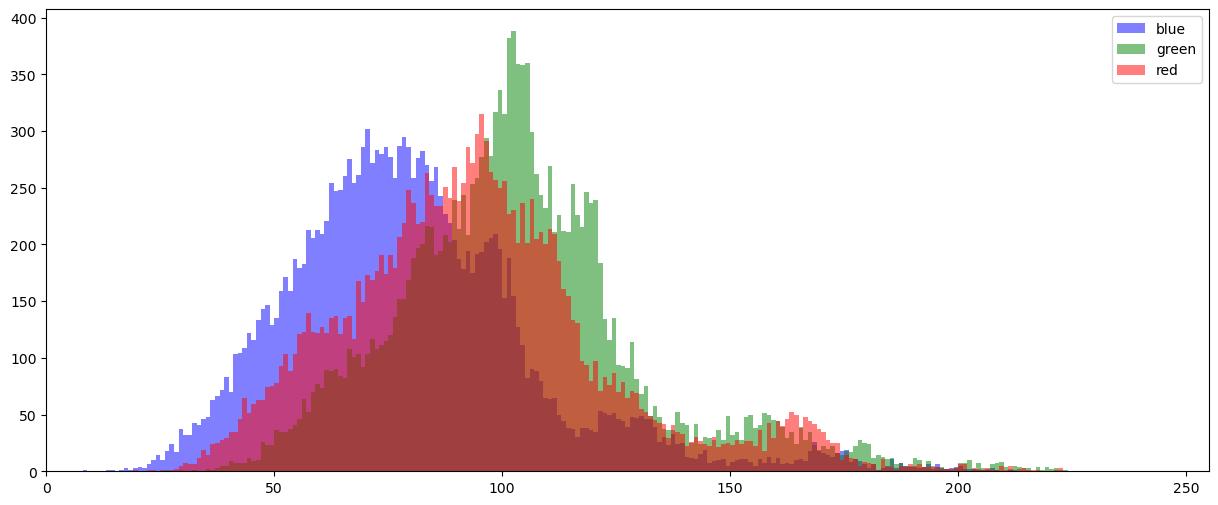

In [ ]:
jpg_channels = ['blue','green','red']
jpg_channel_colors = ['b','g','r']

fig, ax = plt.subplots(figsize=(15,6))

for i in range(len(jpg_channels)):
    ax.hist(img[:,:,i].flatten(), bins=np.arange(256),
            label=jpg_channels[i], color=jpg_channel_colors[i], alpha=0.5)
    ax.legend()

ax.set_xlim(0,255)

plt.show(fig)

Transfer learning

In [ ]:
import tensorflow as tf
tf.__version__

'2.18.0'

Image preprocessing

In [ ]:
#paths

train_path=image_df_train['path'].copy().values
val_path=image_df_val['path'].copy().values
test_path=image_df_test['path'].copy().values

# Labels
train_labels = np.zeros(len(image_df_train), dtype=np.int8)
train_labels[image_df_train['damage'].values == 'damage'] = 1

val_labels = np.zeros(len(image_df_val), dtype=np.int8)
val_labels[image_df_val['damage'].values == 'damage'] = 1

test_labels = np.zeros(len(image_df_test), dtype=np.int8)
test_labels[image_df_test['damage'].values == 'damage'] = 1

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((train_path, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_path, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_path, test_labels))

# note that the `numpy()` function is required to grab the actual values from the Dataset
for path, label in train_ds.take(5):
    print("path  : ", path.numpy().decode('utf-8'))
    print("label : ", label.numpy())

path  :  C:\Users\faris\Desktop\mini2\train_another\damage\-96.860867_28.363774.jpeg
label :  1
path  :  C:\Users\faris\Desktop\mini2\dataset\train_another\damage\-96.860867_28.363774.jpeg
label :  1
path  :  C:\Users\faris\Desktop\mini2\train_another\damage\-96.861175_28.36379.jpeg
label :  1
path  :  C:\Users\faris\Desktop\mini2\dataset\train_another\damage\-96.861175_28.36379.jpeg
label :  1
path  :  C:\Users\faris\Desktop\mini2\train_another\damage\-96.90485699999999_28.375248.jpeg
label :  1


In [ ]:
def cv2_imread(path, label):
    # read in the image, getting the string of the path via eager execution
    img = cv2.imread(path.numpy().decode('utf-8'), cv2.IMREAD_UNCHANGED)
    # change from BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img, label

# this function assumes that the image has been read in, and does some transformations on it
# note that only tensorflow functions are used here
def tf_cleanup(img, label):
    # convert to Tensor
    img = tf.convert_to_tensor(img)
    # unclear why, but the jpeg is read in as uint16 - convert to uint8
    img = tf.dtypes.cast(img, tf.uint8)
    # set the shape of the Tensor
    img.set_shape((128, 128, 3))
    # convert to float32, scaling from uint8 (0-255) to float32 (0-1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    # resize the image
    img = tf.image.resize(img, [128, 128])
    # convert the labels into a Tensor and set the shape
    label = tf.convert_to_tensor(label)
    label.set_shape(())
    return img, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
# map the cv2 wrapper function using `tf.py_function`
train_ds = train_ds.map(lambda path, label: tuple(tf.py_function(cv2_imread, [path, label], [tf.uint16, label.dtype])),
                        num_parallel_calls=AUTOTUNE)

val_ds = val_ds.map(lambda path, label: tuple(tf.py_function(cv2_imread, [path, label], [tf.uint16, label.dtype])),
                    num_parallel_calls=AUTOTUNE)

test_ds = test_ds.map(lambda path, label: tuple(tf.py_function(cv2_imread, [path, label], [tf.uint16, label.dtype])),
                      num_parallel_calls=AUTOTUNE)

# map the TensorFlow transformation function - no need to wrap
train_ds = train_ds.map(tf_cleanup, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(tf_cleanup, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(tf_cleanup, num_parallel_calls=AUTOTUNE)

In [ ]:
def rotate_augmentation(img, label):
    # Rotate 0, 90, 180, or 270 degrees with 25% probability for each
    img = tf.image.rot90(img, tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32, seed=1111))
    return img, label

def flip_augmentation(img, label):
    # Flip with 50% probability for left-right and up-down
    img = tf.image.random_flip_left_right(img, seed=2222)
    img = tf.image.random_flip_up_down(img, seed=3333)
    return img, label

# Map the augmentations, creating a new dataset
augmented_train_ds = train_ds.map(rotate_augmentation, num_parallel_calls=AUTOTUNE)
augmented_train_ds = augmented_train_ds.map(flip_augmentation, num_parallel_calls=AUTOTUNE)

augmented_val_ds = val_ds.map(rotate_augmentation, num_parallel_calls=AUTOTUNE)
augmented_val_ds = augmented_val_ds.map(flip_augmentation, num_parallel_calls=AUTOTUNE)

In [ ]:
# Double the number of samples in the training and validation splits, due to our augmentation procedure
n_train = len(train_labels) * 2
n_val = len(val_labels) * 2
n_test = len(test_labels)

# Shuffle over the entire dataset, seeding the shuffling for reproducible results
train_ds = train_ds.shuffle(n_train, seed=208, reshuffle_each_iteration=True)
val_ds = val_ds.shuffle(n_val, seed=208, reshuffle_each_iteration=True)
test_ds = test_ds.shuffle(n_test, seed=208, reshuffle_each_iteration=True)

# Check to make sure everything was read in correctly
n_train_check = 0
for element in train_ds:
    n_train_check = n_train_check + 1
print(n_train_check)

20000


In [ ]:
n_val_check = 0
for element in val_ds:
    n_val_check = n_val_check + 1
print(n_val_check)

4000


In [ ]:
# check that the image was read in correctly
for image, label in train_ds.take(1):
    print("image shape : ", image.numpy().shape)
    print("label       : ", label.numpy())

# Output:
# image shape :  (128, 128, 3)
# label       :  1

# Batch the data. A batch size of 32 seems like a common starting point,
# and using powers of 2 is preferred when using a GPU.
BATCH_SIZE = 32

train_batches_ds = train_ds.batch(BATCH_SIZE)
val_batches_ds = val_ds.batch(BATCH_SIZE)
test_batches_ds = test_ds.batch(BATCH_SIZE)

image shape :  (128, 128, 3)
label       :  1


In [ ]:
BATCH_SIZE = 32
train_batch_ds = train_ds.batch(BATCH_SIZE)
val_batches_ds = val_ds.batch(BATCH_SIZE)
test_batches_ds = test_ds.batch(BATCH_SIZE)

In [ ]:
for image_batch, label_batch in train_batches_ds.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 128, 128, 3)
[0 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1 1]


Loading VGG16 Model

In [ ]:
IMG_SHAPE = (128, 128, 3)

# create the base model from the pre-trained model VGG16
# note that, if using a Kaggle server, internet has to be turned on
pretrained_model = tf.keras.applications.vgg16.VGG16(input_shape=IMG_SHAPE,
                                                     include_top=False,
                                                     weights='imagenet')

# freeze the convolutional base
pretrained_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 89s 2us/step


In [ ]:
feature_batch = pretrained_model(image_batch)
print(feature_batch.shape)

(32, 4, 4, 512)


In [ ]:
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)  # Output: (32, 512)

# Apply a Dense layer to convert features into a single prediction per image
# No activation function needed as this is a raw prediction value

# Set the initializers with a seed for reproducible behavior
prediction_layer = tf.keras.layers.Dense(1,
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=1992),
    bias_initializer=tf.keras.initializers.GlorotUniform(seed=1992))

prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 512)
(32, 1)


In [ ]:
model = tf.keras.Sequential([
    pretrained_model,
    global_average_layer,
    prediction_layer
])

base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

train the model

In [ ]:
initial_epochs = 15
steps_per_epoch = n_train // BATCH_SIZE
validation_steps = 20

loss0, accuracy0 = model.evaluate(val_batches_ds, steps=validation_steps)

history = model.fit(train_batches_ds,
                    epochs=initial_epochs,
                    validation_data=val_batches_ds,
                    validation_steps=validation_steps)

20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 918ms/step - accuracy: 0.4833 - loss: 0.8863
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10216s 16s/step - accuracy: 0.5449 - loss: 0.7180 - val_accuracy: 0.5453 - val_loss: 0.5748
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 729s 1s/step - accuracy: 0.6084 - loss: 0.5553 - val_accuracy: 0.7641 - val_loss: 0.4857
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 725s 1s/step - accuracy: 0.7741 - loss: 0.4870 - val_accuracy: 0.7656 - val_loss: 0.4636
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5219s 8s/step - accuracy: 0.8198 - loss: 0.4370 - val_accuracy: 0.8141 - val_loss: 0.4114
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1006s 1s/step - accuracy: 0.8448 - loss: 0.3990 - val_accuracy: 0.8313 - val_loss: 0.4032
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 966s 1s/step - accuracy: 0.8499 - loss: 0.3766 - val_accuracy: 0.8719 - val_loss: 0.3533
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 687s 952ms/step - accuracy: 0.8605 - loss: 0.3536 - val_accuracy: 0.8672 - val_loss: 0.3367
Epoch 8/15
62

curve

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)

x_plot = np.arange(1, initial_epochs+1)

ax[0].plot(x_plot, acc, '+-', label='training')
ax[0].plot(x_plot, val_acc, '+-', label='validation')
ax[0].legend()
ax[0].set_ylabel('accuracy')
ax[0].set_ylim(0.5, 1)
ax[0].grid(ls='--', c='C7')
ax[0].set_title('accuracy')

ax[1].plot(x_plot, loss, '+-', label='training')
ax[1].plot(x_plot, val_loss, '+-', label='validation')
ax[1].legend()
ax[1].set_ylabel('cross entropy')
ax[1].set_ylim(0, 1)
ax[1].grid(ls='--', c='C7')
ax[1].set_title('loss')
ax[1].set_xlabel('epoch')
plt.show()

NameError: name 'history' is not defined